In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop, Nadam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing import image_dataset_from_directory, image
from tensorflow.keras.models import load_model
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
train_dir="/content/drive/MyDrive/dogs_vs_cats/train"
test_dir="/content/drive/MyDrive/dogs_vs_cats/test"

In [ ]:
train_dataset=image_dataset_from_directory(
train_dir,
image_size=(128, 128),
label_mode='binary'
)

Found 20340 files belonging to 2 classes.


In [ ]:
test_dataset=image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    label_mode='binary'
)

Found 5000 files belonging to 2 classes.


In [ ]:
normalization_layer=tf.keras.layers.Rescaling(1./255)
train_dataset=train_dataset.map(lambda x,y : (normalization_layer(x),y))
test_dataset=test_dataset.map(lambda x,y : (normalization_layer(x),y))


In [ ]:
def create_model():
  model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
  ])
  return model

In [ ]:
optimizers = {
    'SGD': SGD(),
    'Adam': Adam(),
    'Adagrad': Adagrad(),
    'RMSprop': RMSprop(),
    'Nadam': Nadam()
}

In [ ]:
results = {}

In [ ]:
for opt_name, optimizer in optimizers.items():
    print(f"\nTraining with optimizer: {opt_name}")

    model=create_model()
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    start_time = time.time()

    history = model.fit(train_dataset,
                        epochs=5,
                        validation_data=test_dataset,
                        verbose=2)
    end_time = time.time()
    elapsed_time = end_time - start_time

    test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)

    results[opt_name] = {
        'history': history.history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'training_time': elapsed_time
    }


Training with optimizer: SGD
Epoch 1/5
636/636 - 116s - loss: 0.6816 - accuracy: 0.5580 - val_loss: 0.6608 - val_accuracy: 0.6382 - 116s/epoch - 182ms/step
Epoch 2/5
636/636 - 68s - loss: 0.6550 - accuracy: 0.6088 - val_loss: 0.6505 - val_accuracy: 0.6076 - 68s/epoch - 108ms/step
Epoch 3/5
636/636 - 69s - loss: 0.6294 - accuracy: 0.6420 - val_loss: 0.6067 - val_accuracy: 0.6792 - 69s/epoch - 109ms/step
Epoch 4/5
636/636 - 69s - loss: 0.5980 - accuracy: 0.6749 - val_loss: 0.5800 - val_accuracy: 0.6902 - 69s/epoch - 109ms/step
Epoch 5/5
636/636 - 68s - loss: 0.5609 - accuracy: 0.7120 - val_loss: 0.5459 - val_accuracy: 0.7266 - 68s/epoch - 107ms/step

Training with optimizer: Adam
Epoch 1/5
636/636 - 73s - loss: 0.6032 - accuracy: 0.6581 - val_loss: 0.5493 - val_accuracy: 0.7260 - 73s/epoch - 115ms/step
Epoch 2/5
636/636 - 73s - loss: 0.4688 - accuracy: 0.7770 - val_loss: 0.4392 - val_accuracy: 0.7998 - 73s/epoch - 114ms/step
Epoch 3/5
636/636 - 71s - loss: 0.3825 - accuracy: 0.8273 - va

In [ ]:
model.save('cats_vs_dog_classifier.h5')
print("\nModel saved as 'cats_vs_dog_classifier.h5'. ")


Model saved as 'cats_vs_dog_classifier.h5'. 


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


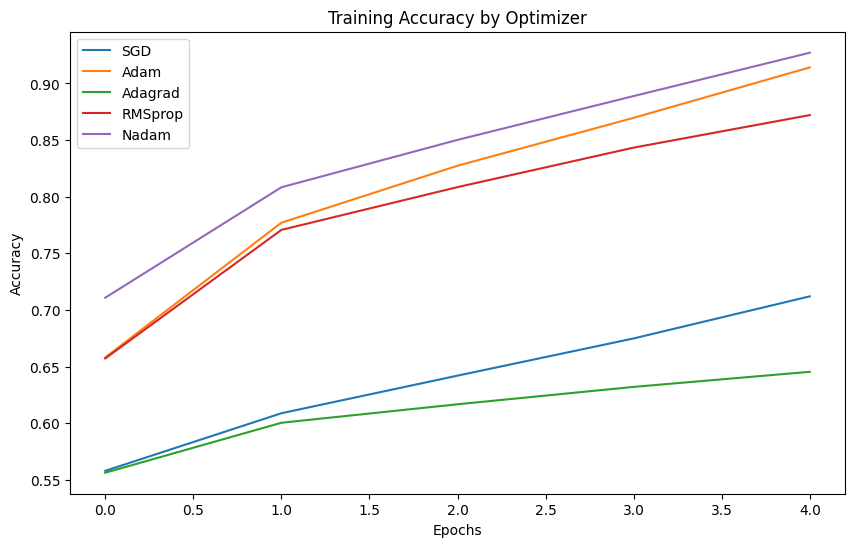

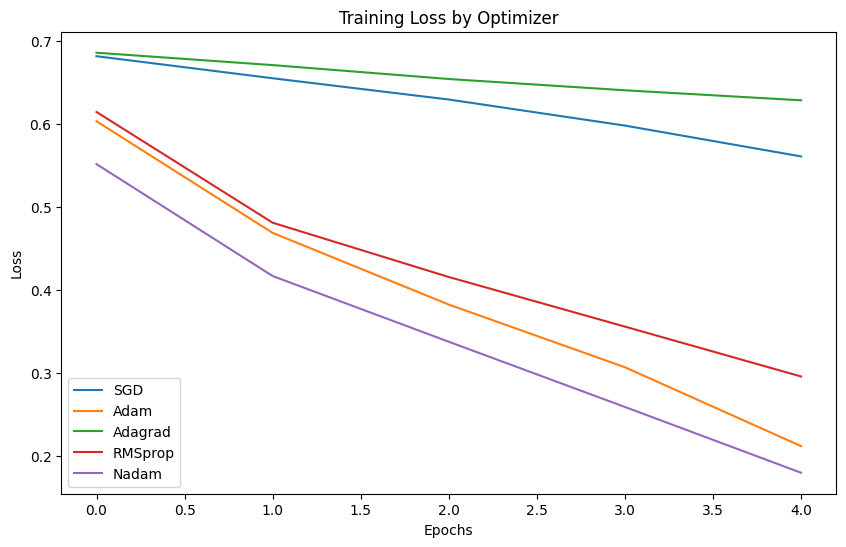

In [ ]:
for metric in ['accuracy', 'loss']:
    plt.figure(figsize=(10, 6)) # Create a new figure for each metric
    for opt_name, result in results.items():
        plt.plot(result['history'][metric], label=opt_name) # Plot the metric for each optimizer
    plt.title(f'Training {metric.capitalize()} by Optimizer')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()

In [ ]:
for opt_name, result in results.items():
    print(f"Optimizer: {opt_name}")
    print(f"Test Loss: {result['test_loss']}")
    print(f"Test Accuracy: {result['test_accuracy']}")
    print(f"Training Time: {result['training_time']} seconds\n")

Optimizer: SGD
Test Loss: 0.5459129214286804
Test Accuracy: 0.7265999913215637
Training Time: 391.07698607444763 seconds

Optimizer: Adam
Test Loss: 0.41686299443244934
Test Accuracy: 0.8306000232696533
Training Time: 357.2921578884125 seconds

Optimizer: Adagrad
Test Loss: 0.6425237655639648
Test Accuracy: 0.6218000054359436
Training Time: 343.2666389942169 seconds

Optimizer: RMSprop
Test Loss: 0.4014762341976166
Test Accuracy: 0.8285999894142151
Training Time: 343.8933153152466 seconds

Optimizer: Nadam
Test Loss: 0.44137564301490784
Test Accuracy: 0.847000002861023
Training Time: 365.7795081138611 seconds



1/1 [==============================] - 0s 108ms/step
The image is predicted to be a Cat with 82.39% confidence.


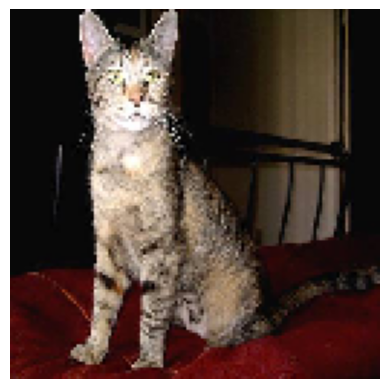

In [ ]:
model = load_model('cats_vs_dog_classifier.h5')

def classify_image(image_path, model):
    img=image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    if prediction[0] > 0.5:
        print(f"The image is predicted to be a Dog with {prediction[0][0]*100:.2f}% confidence.")
    else:
        print(f"The image is predicted to be a Cat with {(1-prediction[0][0])*100:.2f}% confidence.")

    plt.imshow(img)
    plt.axis('off')
    plt.show()


classify_image('/content/drive/MyDrive/dogs_vs_cats/test/cats/cat.10000.jpg', model)



1/1 [==============================] - 0s 28ms/step
The image is predicted to be a Dog with 100.00% confidence.


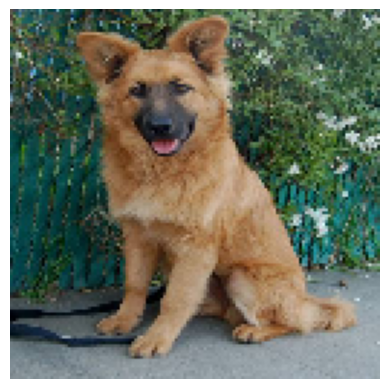

In [ ]:
classify_image('/content/drive/MyDrive/dogs_vs_cats/test/dogs/dog.10014.jpg', model)